# QUADCOIL coil and equilibrium optimization

## What is QUADCOIL
QUADCOIL [1] is a new differentiable winding surface code. Unlike REGCOIL, QUADCOIL can solve a general QCQP:

$$\min f(\Phi_{sv})$$
$$g_i(\Phi_{sv})\leq 0$$
$$h_j(\Phi_{sv}) =0 $$

where $f$, $g_i$, and $h_j$ can be any quadratic functions. It also includes a winding surface generator that automatically removes self-intersections. QUADCOIL is a standalone code built on the same numerical tools as DESC. To use the QUADCOIL integrations, please first [install QUADCOIL here](https://quadcoil.readthedocs.io/en/latest/index.html).

Compared to REGCOIL, it can:

1) Models more realistic quantites, such as:
    - Magnetic field errors (including $\chi^2_B$, which REGCOIL uses).
    - Sheet current density and topology (including $\chi^2_K$, which REGCOIL uses).
    - Dipole density and sparsity.
    - Lorentz force.
    - Filament coil curvature.
2) Generate better-behaved winding surfaces.
3) Supports inequality and equality constraints.
4) (Using constraints) directly specify target values instead of scanning
a regularization weight $\lambda_{regularization}$.
5) Serve as a coil complexity metric in DESC equilibrium optimization. 

## Outline

This tutorial shows how to use QUADCOIL for the following:

1) Solving a NESCOIL problem.
2) Solving a REGCOIL-like constrained problem.
3) Solving a force minimization problem.
4) Performing equilibrium optimization using QUADCOIL as a coil complexity proxy. We will reproduce the numerical example in [2] and show how to use QUADCOIL to create a ARIES-CS-like equilibrium with low coil forces.

If you have access to a GPU, uncomment the following two lines before any DESC or JAX related imports. You should see about an order of magnitude speed improvement with only these two lines of code!

In [1]:
from desc import set_device

set_device("gpu")

Importing libraries

In [2]:
import desc
import time
import matplotlib.pyplot as plt
import numpy as np
from desc.backend import jnp
from desc.grid import LinearGrid
from desc.plotting import plot_2d
from desc.objectives import (
    QuadcoilProxy,
    QuadraticFlux,
    SurfaceCurrentRegularization,
    QuasisymmetryTripleProduct,
    Volume,
    ForceBalance,
    FixBoundaryR,
    FixBoundaryZ,
    FixPsi,
    FixPressure,
    FixIota,
    ObjectiveFunction,
)
from desc.optimize import Optimizer
from desc.magnetic_fields import solve_regularized_surface_current
from desc.equilibrium import EquilibriaFamily
from quadcoil.quantity import f_B, f_K, Phi_with_net_current, K, f_l1_force_cyl

As mentioned in [DESC Documentation on performance tips](https://desc-docs.readthedocs.io/en/latest/performance_tips.html), one can use compilation cache directory to reduce the compilation overhead time. Note: One needs to create `jax-caches` folder manually.

In [3]:
# import jax

# jax.config.update("jax_compilation_cache_dir", "../jax-caches")
# jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
# jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)

import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../../"))

We use the AREIS-CS equilibrium for this example. ARIES-CS is used as the initial state in the second numerical example in [2].

In [4]:
aries_eq = desc.examples.get("ARIES-CS")

## General settings
First, define some QUADCOIL settings.

In [5]:
# Settings
mpol = 8  # Num. poloidal modes in the current potential
ntor = 8  # Num. toroidal modes in the current potential
# Controls the resolution of the plasma surface integration.
# Integration in quadcoil is naively performed using summation
# so we recommend at least 16 here.
# This corresponds to a (33 x 33) grid.
plasma_coil_distance = (
    1.3  # 1.64 is the Wiedman value # 1.5 m is a common rule-of-thumb value
)
coil_coil_distance = 0.77  # 1.10 is the Wiedman value
coil_per_half_fp = 3  # 3 is the Wiedman value
curvature_target = 0.88  # 0.88 is the Wiedman value
# f_B_target_norm = 1e-4
# radius_of_curvature = 0.5 # 0.5m is the infinity two value
# Resolution for sampling objectives
quadpoints_phi = jnp.linspace(0, 1 / aries_eq.NFP, 33, endpoint=False)
quadpoints_theta = jnp.linspace(0, 1, 33, endpoint=False)

The QUADCOIL objective is mostly controlled using a dictionary, `quadcoil_kwargs`
that contains arguments that would otherwise be passed into a call of `quadcoil.quadcoil()`.
For a tutorial on `quadcoil.quadcoil()`, 
[see here](https://quadcoil.readthedocs.io/en/latest/tutorial_inputs.html). 


If your `quadcoil_kwargs` is good for directly calling `quadcoil.quadcoil(**quadcoil_kwargs)`, it will also work here.


Because a `QuadcoilProxy` is attached to an `Equilibrium`, the following arguments
will instead be calculated from the `Equilibrium`. Their values will be ignored if provided.

```
"nfp"                           # Num. field period
"stellsym",                     # Stellarator symmetry
"plasma_mpol",                  # Plasma poloidal Fourier mode number 
"plasma_ntor",                  # Plasma toroidal Fourier mode number 
"plasma_quadpoints_phi",        # Plasma integral quadrature points. Will be 
"plasma_quadpoints_theta",      # auto-generated from plasma_M_theta and plasma_N_phi.
"plasma_dofs",                  # Plasma surface Fourier coefficients
"net_poloidal_current_amperes", # Net poloidal current required on the winding surface
"Bnormal_plasma",               # B normal on the plasma boundary 
"metric_name",                  # What coil properties to output. Will be controlled 
                                # by an identically named argument to QuadcoilProxy
"value_only"                    # Controls whether to skip adjoint differentiation.
```

In [6]:
quadcoil_kwargs_basic = {
    "mpol": mpol,
    "ntor": ntor,
    # Resolutions for evaluating winding-surface
    # pointwise objectives and plotting.
    # Note that this does not control the resolution
    # for evaluating winding surface integrals.
    # The integral resolution is controlled using
    # winding_quadpoints_phi and winding_quadpoints_theta.
    # Here, we use the default value of 33x(32xnfp), which
    # is often good enough.
    "quadpoints_phi": quadpoints_phi,
    "quadpoints_theta": quadpoints_theta,
    "plasma_coil_distance": plasma_coil_distance,
}

If you have access to a GPU, uncomment the following two lines before any DESC or JAX related imports. You should see about an order of magnitude speed improvement with only these two lines of code!

In [7]:
# import jax

# jax.config.update("jax_compilation_cache_dir", "../jax-caches")
# jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
# jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)

import sys
import os
import desc

sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../../"))

We"ll first load the AREIS-CS equilibrium that [2] uses as the initial state.

In [8]:
aries_eq = desc.examples.get("ARIES-CS")

## 1. Solving the NESCOIL problem
As a first example, we solve the NESCOIL problem:
$$\min_{\Phi'} \chi^2_B.$$
Here $\chi^2_B$ is the squared flux at the plasma boundary.

The objectives and constraints in quadcoil are chosen
by feeding strings representing the name of the 
quantities as arguments. The first example, the NESCOIL
problem, has one objective term (the squared flux 
`"f_B"`) and no constraints.

In [9]:
quadcoil_kwargs_nescoil = quadcoil_kwargs_basic | {
    # The NESCOIL problem only contains the squared
    # flux objective. In QUADCOIL, this quantity is called
    # f_B.
    "objective_name": "f_B",
    # The NESCOIL problem is simple enough to need no normalization
    # constants. In the next example we will discuss how to choose
    # this constant.
    "objective_unit": None,
}

QUADCOIL is integrated into DESC as an objective function. 

In [10]:
# Define a QuadcoilProxy with the simplest possible
# signature.
objective_nescoil = QuadcoilProxy(
    eq=aries_eq,
    quadcoil_kwargs=quadcoil_kwargs_nescoil,
    vacuum=False,
    # If you have additional filament/planar coils, put the CoilSet here.
    # field=[],
)
objective_nescoil.build()

Precomputing transforms


### Calling QUADCOIL (outputting QUADCOIL types)
To call QUADCOIL, use `QuadcoilProxy.solve_quadcoil()`. The signature of this function is the same as `Objective.compute()` or `Objective.compute_scalar()`. The output is the same as `quadcoil.quadcoil()`. See [here](https://quadcoil.readthedocs.io/en/latest/tutorial_outputs.html) for a tutorial for interpreting QUADCOIL outputs.

Note that calling `QuadcoilProxy` in DESC is slightly more costly than directly calling `quadcoil.quadcoil()`. This is because `QuadcoilProxy` also calculates $B_\text{normal}$ and the net poloidal current.

In [11]:
# The outputs are:
# -   out_dict: a dictionary storing the value and gradients of the
#     metrics chosen in metric_name. By default the chosen metric
#     f_obj, the exact same function that QUADCOIL uses as the
#     objective function.
# -   qp: a quadcoil container for the winding surface, plasma surface
#     and plasma B normal. One of the 2 arguments required to evaluate
#     any quantity in QUADCOIL
# -   dofs: a dict containing the current potential's Fourier coefficients
#     and additional slack variables (if any). The other one of the 2
#     arguments required to evaluate any quantity in QUADCOIL
# -   status: a dict containing some status of the optimizer.
(out_dict_nescoil, qp_nescoil, dofs_nescoil, status_nescoil) = (
    objective_nescoil.solve_quadcoil(
        # Like Objective.compute(), the xs of the equilibrium
        # must be passed in as the *arg.
        *objective_nescoil.xs(aries_eq)
    )
)
print("The squared flux is", f_B(qp_nescoil, dofs_nescoil), "T^2m^2")

/home/lf2869/Documents/Codes/quadcoil/src/quadcoil/wrapper.py:37: UserWarning: Bnormal_plasma provided, inputs for plasma_quadpoints_phi and plasma_quadpoints_theta will be ignored.
  warnings.warn(


The squared flux is 1.0540637910635586 T^2m^2


Plotting the current contours using QUADCOIL.
The full Phi (with both single-valued and secular
components) is called Phi_with_net_current.
Physical quantities in QUADCOIL are all stored 
in `quadcoil.quantity`. All quantities take the following
two arguments:
- `qp` This is an object storing the plasma surface, winding 
surface, and $B_\text{norm}$.
- `dofs` (a dictionary
storing $\Phi$ and any slack variables)

These are the second and third outputs of `quadcoil.quadcoil()`
or `QuadcoilProxy.solve_quadcoil()`.

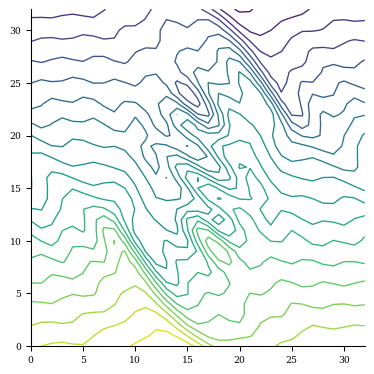

In [12]:
plt.figure(figsize=(4, 4))
# Phi_with_net_current is imported from quadcoil.quantity
plt.contour(Phi_with_net_current(qp_nescoil, dofs_nescoil), levels=20)

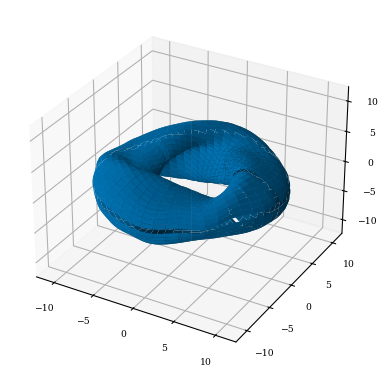

In [13]:
# If you have simsopt installed, uncomment this to
# plot QUADCOIL surfaces using simsopt"s plotting
# utils.
qp_nescoil.winding_surface.plot()

### Calling QUADCOIL (outputting DESC REGCOIL types)
Alternatively, one can also run
```QuadcoilProxy.solve_quadcoil_surface_current()``` 
to call QUADCOIL and output the result as a DESC object (see the DESC REGCOIL tutorial)

In [14]:
scf_nescoil = objective_nescoil.solve_quadcoil_surface_current(
    # Like Objective.compute(), the xs of the equilibrium
    # must be passed in as the *arg.
    *objective_nescoil.xs(aries_eq)
)

### Consistency with DESC's built-in REGCOIL
We now demonstrate the consistency between QUADCOIL and DESC's built-in REGCOIL.

In [15]:
# Solving the NESCOIL problem using DESC's built in REGCOIL.
# Please see the REGCOIL-like coil optimization tutorial
fields, data = solve_regularized_surface_current(
    scf_nescoil,  # the surface current field whose geometry and Phi resolution will be used
    eq=aries_eq,  # the Equilibrium object to minimize Bn on the surface of
    source_grid=objective_nescoil.constants["source_grid"],  # source grid
    eval_grid=objective_nescoil.constants["eval_grid"],  # evaluation grid
    current_helicity=(
        1,
        0,
    ),
    lambda_regularization=jnp.array([0]),
    vacuum=False,
    regularization_type="regcoil",
    chunk_size=40,
)

##########################################################
Calculating Phi_SV for lambda_regularization = 0.00000e+00
##########################################################
chi^2 B = 2.10990e+00
min Bnormal = 7.58584e-15 (T)
Max Bnormal = 2.18612e-01 (T)
Avg Bnormal = 3.00948e-02 (T)
min Bnormal = 1.24158e-15 (unitless)
Max Bnormal = 3.57805e-02 (unitless)
Avg Bnormal = 4.92564e-03 (unitless)


Difference between Phi coefficients of DESC REGCOIL and QUADCOIL Fourier coefficients
Maximum absolute:  29413.851731878647
Mininum absolute:  4.44800912658684
Average absolute:  3807.8703983615937
Maximum normalized (by max Phi):  0.006661441697821326
Mininum normalized (by max Phi):  1.0073537372197437e-06
Average normalized (by max Phi):  0.0008623796326563354


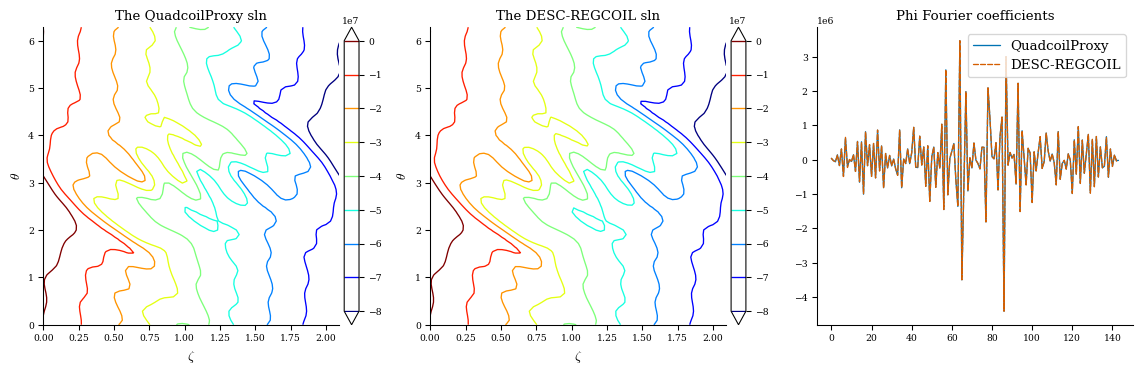

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
plot_2d(scf_nescoil, "Phi", levels=10, filled=False, ax=axs[0])
axs[0].set_title("The QuadcoilProxy sln")
plot_2d(fields[0], "Phi", levels=10, filled=False, ax=axs[1])
axs[1].set_title("The DESC-REGCOIL sln")
axs[2].plot(scf_nescoil.Phi_mn, label="QuadcoilProxy")
axs[2].plot(fields[0].Phi_mn, label="DESC-REGCOIL", linestyle="dashed")
axs[2].legend()
axs[2].set_title("Phi Fourier coefficients")
norm = jnp.max(jnp.abs(fields[0].Phi_mn))
err_phi = jnp.abs(scf_nescoil.Phi_mn - fields[0].Phi_mn)
print(
    "Difference between Phi coefficients of DESC "
    "REGCOIL and QUADCOIL Fourier coefficients"
)
print("Maximum absolute: ", jnp.max(err_phi))
print("Mininum absolute: ", jnp.min(err_phi))
print("Average absolute: ", jnp.average(err_phi))
print("Maximum normalized (by max Phi): ", jnp.max(err_phi) / norm)
print("Mininum normalized (by max Phi): ", jnp.min(err_phi) / norm)
print("Average normalized (by max Phi): ", jnp.average(err_phi) / norm)

## 2. Solving a simple REGCOIL-like constrained problem
As a second example, we solve a REGCOIL-like constrained problem:
$$\min_{\Phi'} \chi^2_K,$$
$$\chi^2_B\leq C_B.$$
Compared to the REGCOIL problem:
$$\min_{\Phi'} \chi^2_B+ \lambda \chi^2_K,$$
One can specify a $\chi^2_B$ target rather than sweeping the regularization
parameter $\lambda$. This saves times and makes it easier to construct coil complexity
proxies.

First, let's solve a REGCOIL problem in DESC to obtain a threshold 
value $C_B$. In a real study, the threshold values
can be based on real engineering requirements.

In [17]:
# Solving the NESCOIL problem using DESC's built in REGCOIL.
# Please see the REGCOIL-like coil optimization tutorial
fields_regcoil, data_regcoil = solve_regularized_surface_current(
    scf_nescoil,  # the surface current field whose geometry and Phi resolution will be used
    eq=aries_eq,  # the Equilibrium object to minimize Bn on the surface of
    source_grid=objective_nescoil.constants["source_grid"],  # source grid
    eval_grid=objective_nescoil.constants["eval_grid"],  # evaluation grid
    current_helicity=(
        1,
        0,
    ),
    lambda_regularization=jnp.array([1e-15]),
    vacuum=False,
    regularization_type="regcoil",
    chunk_size=40,
)

##########################################################
Calculating Phi_SV for lambda_regularization = 1.00000e-15
##########################################################
chi^2 B = 4.88488e+00
min Bnormal = 7.42333e-15 (T)
Max Bnormal = 3.13784e-01 (T)
Avg Bnormal = 4.43411e-02 (T)
min Bnormal = 1.21498e-15 (unitless)
Max Bnormal = 5.13572e-02 (unitless)
Avg Bnormal = 7.25735e-03 (unitless)


In [18]:
obj_flux = QuadraticFlux(
    field=fields[0],  # the field to be optimized
    eq=aries_eq,  # the equilibrium upon which the quadratic flux is being evaluated
    eval_grid=objective_nescoil.constants["eval_grid"],
    field_grid=objective_nescoil.constants["source_grid"],
    vacuum=False,
    bs_chunk_size=10,
    normalize=False,
    normalize_target=False,  # don't use normalizations, to match the REGCOIL problem exactly
)
obj_flux.build()
chi_2_B_regcoil = obj_flux.compute_scalar(*obj_flux.xs(fields_regcoil[0]))

Precomputing transforms


In [19]:
obj_regularization = SurfaceCurrentRegularization(
    surface_current_field=fields[0],
    source_grid=objective_nescoil.constants["source_grid"],
    weight=1,
    normalize=False,
    normalize_target=False,  # don't use normalizations, to match the REGCOIL problem exactly
)  # we will set it to the sqrt of optimal weight from above,
# since DESC will square the weight when making the overall cost fxn
obj_regularization.build()
chi_2_K_regcoil = obj_regularization.compute_scalar(
    *obj_regularization.xs(fields_regcoil[0])
)

Precomputing transforms


In [20]:
# There is a factor of 4pi difference between
# QUADCOIL and DESC as of Mar. 2026, since
# QUADCOIL is calibrated against simsopt's REGCOIL
# implementation. This may change with later versions.
C_B = chi_2_B_regcoil / (4 * jnp.pi**2)
C_K = chi_2_K_regcoil / (4 * jnp.pi**2)
print("Target f_B is:", C_B, "T^2m^2")
print("Target f_K is:", C_K, "T^2m^2")

Target f_B is: 2.442441636833631 T^2m^2
Target f_K is: 1.992594631747012e+16 T^2m^2


### Calling QUADCOIL (outputting DESC REGCOIL types)

In [21]:
quadcoil_kwargs_regcoil = quadcoil_kwargs_basic | {
    # The NESCOIL problem only contains the squared
    # flux objective. In QUADCOIL, this quantity is called
    # f_B.
    "objective_name": "f_K",
    # For a constrained REGCOIL problem, we advise
    # normaizing the objectives and constraints using
    # values measured from known QUADCOIL solution.
    # Empirically this gives much better accuracy than
    # normalizing using equilibrium parameters.
    "objective_unit": C_K,
    # Quantities to constrain. Must be a tuple.
    "constraint_name": ("f_B",),
    # Types of constraints. Must be a tuple.
    # Here, we define a "<=" inequality constraint.
    "constraint_type": ("<=",),
    # Threshold of the constraints. Must be an ndarray.
    "constraint_value": jnp.array([C_B]),
    # Normalizing constants of the constraints.
    # We advise directly using the constraint thresholds
    # if they are non-zero for best numerical behavior.
    # A good alternative choice is f_K(qp_nescoil, dofs_nescoil).
    "constraint_unit": jnp.array([C_B]),
}

In [22]:
# Define a QuadcoilProxy with the simplest possible
# signature.
objective_regcoil = QuadcoilProxy(
    eq=aries_eq,
    quadcoil_kwargs=quadcoil_kwargs_regcoil,
    vacuum=False,
    # If you have additional filament/planar coils, put the CoilSet here.
    # field=[],
)
objective_regcoil.build()

Precomputing transforms


In [23]:
scf_regcoil = objective_regcoil.solve_quadcoil_surface_current(
    # Like Objective.compute(), the xs of the equilibrium
    # must be passed in as the *arg.
    *objective_regcoil.xs(aries_eq)
)

/home/lf2869/Documents/Codes/quadcoil/src/quadcoil/wrapper.py:37: UserWarning: Bnormal_plasma provided, inputs for plasma_quadpoints_phi and plasma_quadpoints_theta will be ignored.
  warnings.warn(


### Consistency with DESC's built-in REGCOIL
Here, we show that the QUADCOIL solution is an exact reproduction
of the REGCOIL solution. This is achieved by directly targeting 
its $\chi^2_B$ value with an inequality constraint.

Difference between Phi coefficients of DESC REGCOIL and QUADCOIL Fourier coefficients
Maximum absolute:  462.28786185069475
Mininum absolute:  4.215652696475445
Average absolute:  115.91969075831103
Maximum normalized (by max Phi):  0.00010156886815130285
Mininum normalized (by max Phi):  9.262174247574944e-07
Average normalized (by max Phi):  2.5468615463179286e-05


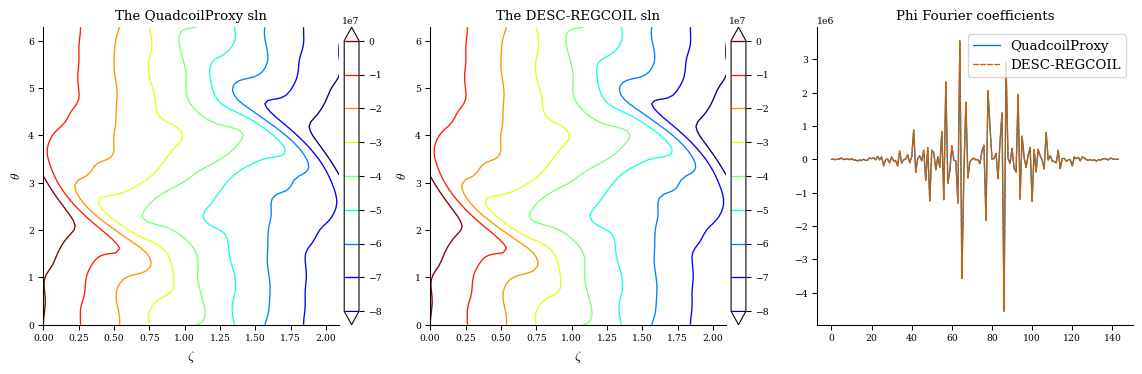

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
plot_2d(scf_regcoil, "Phi", levels=10, filled=False, ax=axs[0])
axs[0].set_title("The QuadcoilProxy sln")
plot_2d(fields_regcoil[0], "Phi", levels=10, filled=False, ax=axs[1])
axs[1].set_title("The DESC-REGCOIL sln")
axs[2].plot(scf_regcoil.Phi_mn, label="QuadcoilProxy")
axs[2].plot(fields_regcoil[0].Phi_mn, label="DESC-REGCOIL", linestyle="dashed")
axs[2].legend()
axs[2].set_title("Phi Fourier coefficients")
norm = jnp.max(jnp.abs(fields_regcoil[0].Phi_mn))
err_phi = jnp.abs(scf_regcoil.Phi_mn - fields_regcoil[0].Phi_mn)
print(
    "Difference between Phi coefficients of DESC "
    "REGCOIL and QUADCOIL Fourier coefficients"
)
print("Maximum absolute: ", jnp.max(err_phi))
print("Mininum absolute: ", jnp.min(err_phi))
print("Average absolute: ", jnp.average(err_phi))
print("Maximum normalized (by max Phi): ", jnp.max(err_phi) / norm)
print("Mininum normalized (by max Phi): ", jnp.min(err_phi) / norm)
print("Average normalized (by max Phi): ", jnp.average(err_phi) / norm)

## 3. A force minimization problem
This section solves a QUADCOIL problem that minimizes the Lorentz force that
the coilset experiences satisfying some required field accuracy $\chi^2_B$.

First, we calculate `K_target`, a target value for current density $|K|$ 
based on the net poloidal currents and coil-coil distance:
$$K_\text{target}\equiv\frac{G}{(\text{coil count})d_{cc}}$$

In [25]:
net_poloidal_current_amperes = qp_nescoil.net_poloidal_current_amperes
coil_count = coil_per_half_fp * 2 * aries_eq.NFP
K_target = net_poloidal_current_amperes / coil_count / coil_coil_distance

### Defining QUADCOIL problems
To perform force optimization, we define two problems.
1. A problem finding the best achievable field
error for a filament coil set with maximum current density
squared $K^2_\text{target}$.
$$\min_{\Phi'} \chi^2_B$$
$$K_\theta\leq0$$
$$|K|^2\leq K^2_\text{target}$$
This problem will be used to calculate normalization constants
and a target value for $\chi^2_B$, $C_{B0}$
3. A filament coil force minimization problem
$$\min_{\Phi'} \int_\text{winding surface}\|L\|_1 dA$$
$$\chi^2_B\leq C_{B0}$$
$$K_\theta\leq0$$
$$|K|^2\leq K^2_\text{target}$$
This problem will be used to calculate normalization constants.
Here, $L$ is the Lorentz force. We used the L-1 norm of forces
as a proxy of its L-2 norm, since the L-1 norm is quadratic and
bounds the L-2 norm via norm equivalence.

In [26]:
# Defining problem 1
quadcoil_kwargs_best_case = quadcoil_kwargs_basic | {
    "objective_name": "f_B",
    "objective_unit": f_B(qp_nescoil, dofs_nescoil),
    "constraint_name": ("K_theta", "f_max_K2"),
    "constraint_type": ("<=", "<="),
    "constraint_unit": (K_target, K_target**2),
    "constraint_value": jnp.array([0, K_target**2]),
}
quadcoil_objective_best_case = QuadcoilProxy(
    eq=aries_eq,
    quadcoil_kwargs=quadcoil_kwargs_best_case,
    metric_name=("f_max_force_cyl",),
    metric_target=jnp.array(
        [
            0.0,
        ]
    ),
    metric_weight=jnp.array(
        [
            1.0,
        ]
    ),
    enable_net_current_plasma=True,
    vacuum=False,
)
quadcoil_objective_best_case.build()

Precomputing transforms


In [27]:
# Solving problem 1
(out_dict_best_case, qp_best_case, dofs_best_case, status_best_case) = (
    quadcoil_objective_best_case.solve_quadcoil(
        *quadcoil_objective_best_case.xs(aries_eq)
    )
)

/home/lf2869/Documents/Codes/quadcoil/src/quadcoil/wrapper.py:37: UserWarning: Bnormal_plasma provided, inputs for plasma_quadpoints_phi and plasma_quadpoints_theta will be ignored.
  warnings.warn(


In [28]:
# Calculating normalization constants.
f_l1_force_cyl_unit = f_l1_force_cyl(qp_best_case, dofs_best_case)
# Defining chi^2_B target. Here, we relax it to be
# 2x the best-achievable value.
f_B_target = f_B(qp_best_case, dofs_best_case) * 2.0

In [29]:
# Defining problem 2
quadcoil_kwargs_force_l1 = quadcoil_kwargs_basic | {
    "objective_name": "f_l1_force_cyl",
    "objective_unit": f_l1_force_cyl_unit,
    "constraint_name": ("f_B", "K_theta", "f_max_K2"),
    "constraint_type": ("<=", "<=", "<="),
    "constraint_unit": (f_B_target, K_target, K_target**2),
    "constraint_value": jnp.array([f_B_target, 0, K_target**2]),
    # We increase the L-BFGS linesearch steps in QUADCOIL
    # since force optimization is tricker
    "max_linesearch_steps": 80,
}

In [30]:
quadcoil_objective_force_l1 = QuadcoilProxy(
    eq=aries_eq,
    quadcoil_kwargs=quadcoil_kwargs_force_l1,
    metric_name=("f_l1_force_cyl",),
    metric_target=jnp.array(
        [
            0.0,
        ]
    ),
    metric_weight=jnp.array(
        [
            1.0,
        ]
    ),
    enable_net_current_plasma=True,
    vacuum=False,
)
quadcoil_objective_force_l1.build()

Precomputing transforms


In [31]:
# Solving problem 2
(out_dict_force_l1, qp_force_l1, dofs_force_l1, status_force_l1) = (
    quadcoil_objective_force_l1.solve_quadcoil(
        *quadcoil_objective_force_l1.xs(aries_eq)
    )
)

/home/lf2869/Documents/Codes/quadcoil/src/quadcoil/wrapper.py:37: UserWarning: Bnormal_plasma provided, inputs for plasma_quadpoints_phi and plasma_quadpoints_theta will be ignored.
  warnings.warn(


Reference case chi^2_B:     2.2882174453116186
Low-force filament chi^2_B: 4.577071758173793
Reference case L-1 force:     32411011098.39411
Low-force filament L-1 force: 29267626440.373383


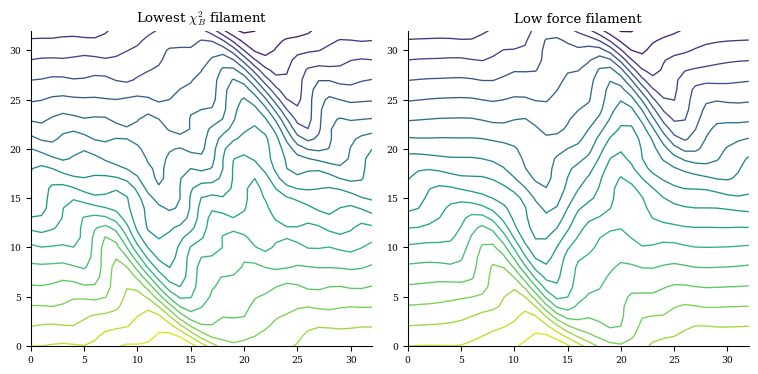

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].contour(Phi_with_net_current(qp_best_case, dofs_best_case), levels=20)
axs[0].set_title(r"Lowest $\chi^2_B$ filament")
axs[1].contour(Phi_with_net_current(qp_force_l1, dofs_force_l1), levels=20)
axs[1].set_title(r"Low force filament")
print("Reference case chi^2_B:    ", f_B(qp_best_case, dofs_best_case))
print("Low-force filament chi^2_B:", f_B(qp_force_l1, dofs_force_l1))
print("Reference case L-1 force:    ", f_l1_force_cyl(qp_best_case, dofs_best_case))
print("Low-force filament L-1 force:", f_l1_force_cyl(qp_force_l1, dofs_force_l1))

## 4. Quasi-single-stage optimization
This is a reproduction of the quasi-single-stage force optimization
in [2].

In [33]:
aries_eq.iota = aries_eq.get_profile("iota")

/home/lf2869/Documents/Codes/DESC/desc/utils.py:572: UserWarning: Setting rotational transform profile on an equilibrium with fixed toroidal current, removing existing toroidal current profile.
  warnings.warn(msg, err)


In [34]:
# Quasi-single-stage with continuation
def quasi_single_stage(
    init_eq,
    file_name,
    quadcoil_kwargs_obj,
    quadcoil_unit,  # unit of metric
    metric_name,
    quadcoil_weight=0.0,
    vol_weight=0.0,
    qs_weight=1.0,
    maxiter=30,  # Maximum iteration per Fourier continuation
    max_k=None,  # Maximum continuation boundary mode number
    printout=False,  # Whether to run dummy optimization even when data exists for printout.
):

    # ----- Calculating targets -----
    # Equilibrium optimization targets in this examples are
    # calculated from the initial state, so that the QUADCOIL
    # proxy is minimized while maintaining other plasma parameters.
    # Building grids
    # Volume
    vol = init_eq.compute(["V"])["V"]
    eqfam = EquilibriaFamily(init_eq)
    # # Triple product QS
    qs_objective_init = QuasisymmetryTripleProduct(
        init_eq,
    )
    qs_objective_init.build()
    qs_bound = jnp.abs(
        qs_objective_init.compute(*qs_objective_init.xs(init_eq))
        / qs_objective_init.normalization
    )

    out_list = []

    # ----- Fourier continuation -----
    if not max_k:
        max_k = init_eq.M + 1
    else:
        max_k = min(max_k, init_eq.M + 1)
    k_list = range(3, init_eq.M + 1)
    print("Boundary mode steps:", k_list)
    for i in range(len(k_list)):
        k = k_list[i]
        filename_eq = file_name + "_eq_" + str(k) + ".h5"
        filename_qf = file_name + "_qf_" + str(k) + ".h5"
        filename_time = file_name + "_time_" + str(k) + ".npy"
        filename_history = file_name + "_history_" + str(k) + ".pickle"
        filename_log = file_name + "_log_" + str(k) + ".txt"

        # ----- Objectives -----
        init_eq_k = eqfam[-1].copy()
        qs_objective = QuasisymmetryTripleProduct(
            eq=init_eq_k,
            bounds=(-qs_bound, qs_bound),
            normalize_target=False,
            weight=qs_weight,
        )
        qs_objective.build()
        obj_list_base = [
            Volume(
                eq=init_eq_k,
                target=vol,
                weight=vol_weight,
            ),
            qs_objective,
        ]
        #  ----- Constraints -----
        # as opposed to SIMSOPT and STELLOPT where variables are assumed fixed, in DESC
        # we assume variables are free. Here we decide which ones to fix, starting with
        # the major radius (R mode = [0,0,0]) and all modes with m,n > k
        R_modes = np.vstack(
            (
                [0, 0, 0],
                init_eq.surface.R_basis.modes[
                    np.max(np.abs(init_eq.surface.R_basis.modes), 1) > k, :
                ],
            )
        )
        Z_modes = init_eq.surface.Z_basis.modes[
            np.max(np.abs(init_eq.surface.Z_basis.modes), 1) > k, :
        ]
        # next we create the constraints, using the mode number arrays just created
        # if we didn't pass those in, it would fix all the modes (like for the profiles)
        constraints_base = [
            ForceBalance(eq=init_eq_k),
            FixBoundaryR(eq=init_eq_k, modes=R_modes),
            FixBoundaryZ(eq=init_eq_k, modes=Z_modes),
            FixPsi(init_eq_k),
            FixPressure(init_eq_k),
            # Equilibrium is now loaded with fixed iota because we don't
            # care about enforcing vacuum field any more.
            FixIota(init_eq_k),
        ]
        # QS objective
        # Mostly used in quasi-single-stage but also
        # used to get single-stage init guess
        quadcoil_objective_new = QuadcoilProxy(
            eq=init_eq_k,
            quadcoil_kwargs=quadcoil_kwargs_obj,
            metric_name=(metric_name,),
            metric_target=np.array(
                [
                    0.0,
                ]
            ),
            metric_weight=np.array(
                [
                    quadcoil_weight / quadcoil_unit,
                ]
            ),
            normalize=False,
            normalize_target=False,
            name="QUADCOIL Proxy",
            enable_net_current_plasma=True,
            vacuum=False,
        )
        quadcoil_objective_new.build()
        objective = ObjectiveFunction(obj_list_base + [quadcoil_objective_new])
        constraints = constraints_base
        # ----- Performing optimization -----
        try:
            # Run continuation step if the save file does not exist
            if not (os.path.exists(filename_history) and os.path.exists(filename_eq)):
                print("\n==================================")
                print("Optimizing boundary modes M,N <= {}".format(k))
                print("====================================")
                time1 = time.time()
                optimizer = Optimizer("proximal-lsq-auglag")
                eq_new, out = init_eq_k.optimize(
                    objective=objective,
                    constraints=constraints,
                    optimizer=optimizer,
                    maxiter=maxiter,
                    verbose=3,
                    ftol=1e-5,
                    copy=True,
                )
                # Printing continuation stage result
                qs_objective1 = qs_objective.compute_scalar(*qs_objective.xs(init_eq_k))
                quadcoil_objective_new1 = quadcoil_objective_new.compute_scalar(
                    *quadcoil_objective_new.xs(init_eq_k)
                )
                qs_objective2 = qs_objective.compute_scalar(*qs_objective.xs(eq_new))
                quadcoil_objective_new2 = quadcoil_objective_new.compute_scalar(
                    *quadcoil_objective_new.xs(eq_new)
                )
                print("Pre-optimization QS value:", qs_objective1)
                print("Pre-optimization quadcoil value:", quadcoil_objective_new1)
                print("Post-optimization QS value:", qs_objective2)
                print("Post-optimization quadcoil value:", quadcoil_objective_new2)
                time2 = time.time()
                jnp.save(filename_time, time2 - time1)
                eq_new.save(filename_eq)
                # Its important to use binary mode
                with open(filename_history, "wb") as dbfile:  # 'wb' = write binary
                    pickle.dump(out, dbfile)
                with open(filename_log, "w") as f:
                    f.write("Pre-optimization QS value:" + str(qs_objective1))
                    f.write(
                        "Pre-optimization quadcoil value:"
                        + str(quadcoil_objective_new1)
                    )
                    f.write("Post-optimization QS value:" + str(qs_objective2))
                    f.write(
                        "Post-optimization quadcoil value:"
                        + str(quadcoil_objective_new2)
                    )
                    f.write("=== Optimization Result ===\n")
                    f.write(pformat(dict(out), indent=2))
                    f.write("\n")
            # Load continuation step if the save file exists
            else:
                print("Step", k, "exists.")
                if printout and i == len(k_list) - 1:
                    print("Still running a dummy optimization to print out stuff.")
                    optimizer = Optimizer("proximal-lsq-auglag")
                    eq_new, out = init_eq_k.optimize(
                        objective=objective,
                        constraints=constraints,
                        optimizer=optimizer,
                        maxiter=1,
                        verbose=3,
                        ftol=1e-5,
                        copy=True,
                    )
                eq_new = desc.io.load(filename_eq, file_format="hdf5")
                with open(filename_history, "rb") as dbfile:  # 'wb' = write binary
                    out = pickle.load(dbfile)

            eqfam.append(eq_new)
            out_list.append(out)
            eqfam.save(file_name + "_eqfam_" + ".h5")
        except KeyboardInterrupt:
            break
        (_, _, dofs_init, status_init) = quadcoil_objective_new.solve_quadcoil(
            *quadcoil_objective_new.xs(eq_new)
        )

    return eqfam, out_list, quadcoil_objective_new

In [35]:
# Directory for saving data
data_dir = "data_aries_force"
os.makedirs(data_dir, exist_ok=True)
init_eq = aries_eq.copy()

# Weights
quadcoil_weight = 10.0  # 5. # 50. -> 90% improvement, 10x degradation in QS
qs_weight = 500  # Good for muse: 5000.
vol_weight = 30.0

# Running fourier continuation
eqfam_force_l1, out_list_force_l1, quadcoil_objective_force_l1 = quasi_single_stage(
    init_eq=init_eq,
    file_name=data_dir + "/" + "f_force_l1",
    quadcoil_kwargs_obj=quadcoil_kwargs_force_l1,
    quadcoil_unit=f_l1_force_cyl_unit,  # unit of metric
    metric_name="f_l1_force_cyl",
    quadcoil_weight=quadcoil_weight,
    qs_weight=qs_weight,
    vol_weight=vol_weight,
)
new_eq = eqfam_force_l1[-1]

Precomputing transforms
Boundary mode steps: range(3, 13)
Precomputing transforms
Precomputing transforms

Optimizing boundary modes M,N <= 3
Building objective: volume
Precomputing transforms
Timer: Precomputing transforms = 68.3 ms
Timer: Objective build = 498 ms
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 776 ms
Timer: Objective build = 839 ms
Timer: Objective build = 1.43 ms
Timer: Eq Update LinearConstraintProjection build = 4.69 sec


2026-04-24 06:23:36.435626: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.81GiB (rounded to 5164681472)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-04-24 06:23:36.435752: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ********************________________________________________________________________________________
E0424 06:23:36.435773 1668650 pjrt_stream_executor_client.cc:2916] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 5164681296 bytes. [tf-allocator-allocation-error='']


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 5164681296 bytes.

In [ ]:
# Compute quadcoil solution and compare with
(out_dict_aries_l1, qp_aries_l1, dofs_aries_l1, status_aries_l1) = (
    quadcoil_objective_force_l1.solve_quadcoil(
        *quadcoil_objective_force_l1.xs(aries_eq)
    )
)
(out_dict_d, qp_d, dofs_d, status_d) = quadcoil_objective_force_l1.solve_quadcoil(
    *quadcoil_objective_force_l1.xs(new_eq)
)
print("ARIES-CS L1 force:       ", out_dict_aries_l1["f_l1_force_cyl"])
print("New equilibrium L1 force:", out_dict_d["f_l1_force_cyl"])